# EMNIST Letter Classification using HOG and SVM

Computer Vision Midterm

## Import Library

In [1]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from skimage.feature import hog
from skimage import exposure

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

C:\Users\Karin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Create Result Folder

In [2]:
os.makedirs("results", exist_ok=True)

print("Downloading/loading dataset...")

Downloading/loading dataset...


## Download Dataset

In [3]:
path = kagglehub.dataset_download("crawford/emnist")
print("Dataset path:", path)

Dataset path: C:\Users\Karin\.cache\kagglehub\datasets\crawford\emnist\versions\3


## Load CSV Dataset

In [4]:
csv_path = os.path.join(path, "emnist-letters-train.csv")

data = pd.read_csv(
    csv_path,
    header=None,
    dtype=np.uint8
)

print("Dataset loaded successfully")

Dataset loaded successfully


## Create Balanced Dataset

In [5]:
balanced_data = []

### 100 Samples

In [6]:
SAMPLES_PER_CLASS = 100

### otomatis baca label

In [7]:
for label in sorted(data[0].unique()):

    class_samples = data[data[0] == label]

    sampled = class_samples.sample(
        n=SAMPLES_PER_CLASS,
        random_state=42
    )

    balanced_data.append(sampled)

balanced_data = pd.concat(balanced_data)

### shuffle dataset

In [8]:
balanced_data = balanced_data.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Balanced dataset created")
print("Total samples:", len(balanced_data))

Balanced dataset created
Total samples: 2600


## Split Label & Image

In [10]:
labels = balanced_data.iloc[:, 0].values
images = balanced_data.iloc[:, 1:].values

### Display Sample Images

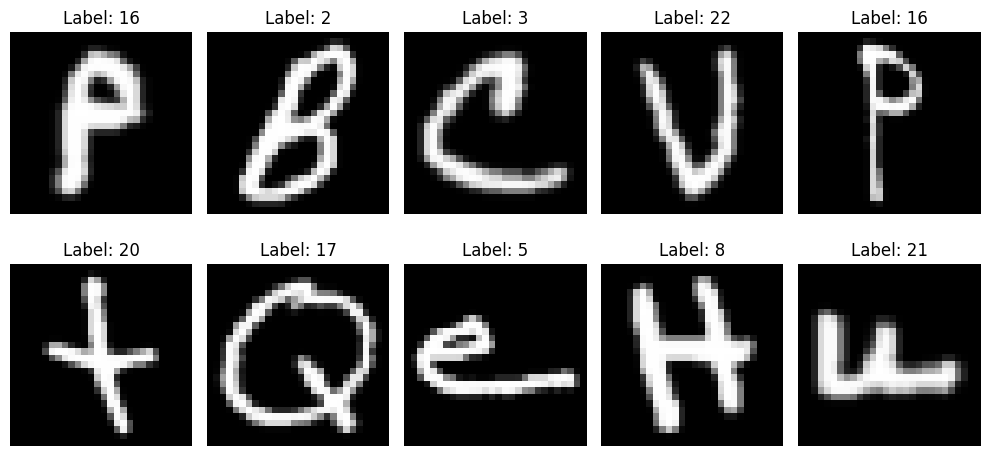

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):

    img = images[i].reshape(28, 28)

    # transpose supaya orientasi benar
    img = np.transpose(img)

    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {labels[i]}")
    ax.axis('off')

plt.tight_layout()
plt.savefig("results/sample_dataset.png")
plt.show()

## HOG Visualization

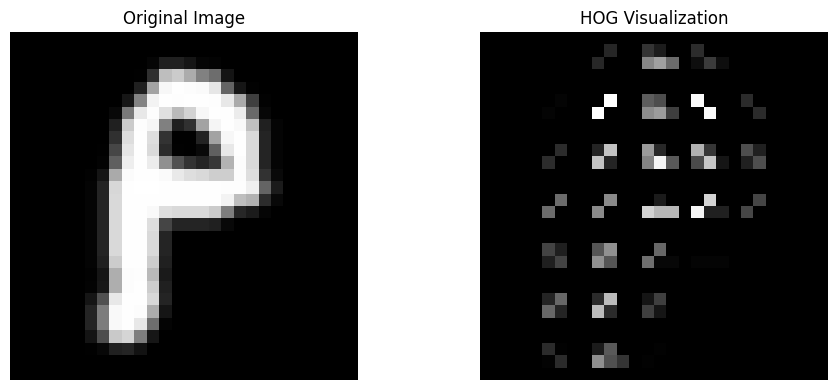

In [14]:
sample_img = images[0].reshape(28, 28)

sample_img = np.transpose(sample_img)

sample_img = sample_img / 255.0

fd, hog_image = hog(
    sample_img,
    orientations=9,
    pixels_per_cell=(4,4),
    cells_per_block=(2,2),
    block_norm='L2-Hys',
    visualize=True
)

hog_image_rescaled = exposure.rescale_intensity(
    hog_image,
    in_range=(0, 10)
)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(sample_img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(hog_image_rescaled, cmap='gray')
plt.title("HOG Visualization")
plt.axis('off')

plt.tight_layout()

plt.savefig("results/hog_visualization.png")

plt.show()

## HOG Feature Extraction

In [15]:
print("Extracting HOG features...")

hog_features = []

for img in images:

    img = img.reshape(28, 28)

    img = np.transpose(img)

    img = img / 255.0

    feature = hog(
        img,
        orientations=9,
        pixels_per_cell=(4, 4),
        cells_per_block=(2, 2),
        block_norm='L2-Hys'
    )

    hog_features.append(feature)

X = np.array(hog_features)
y = np.array(labels)

print("HOG extraction completed")
print("Feature shape:", X.shape)

Extracting HOG features...
HOG extraction completed
Feature shape: (2600, 1296)


## Train Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 2080
Testing samples: 520


## Grid Search SVM

In [17]:
print("Running Grid Search...")

param_grid = {
    'kernel': ['linear', 'rbf'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.1, 0.01]
}

grid_search = GridSearchCV(
    SVC(),
    param_grid,
    cv=3,
    verbose=2,
    n_jobs=1
)

grid_search.fit(X_train, y_train)

print("\nBest Parameters:")
print(grid_search.best_params_)

best_model = grid_search.best_estimator_

Running Grid Search...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   1.2s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   1.4s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   1.8s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   4.6s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   4.9s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   4.6s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   2.1s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   2.2s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   2.2s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   5.1s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   5.0s
[CV] END ................

## Prediction

In [18]:
y_pred = best_model.predict(X_test)

# Evaluation

In [19]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted',
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted',
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted',
    zero_division=0
)

print("\n===== EVALUATION RESULT =====")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")


===== EVALUATION RESULT =====
Accuracy  : 0.8115
Precision : 0.8159
Recall    : 0.8115
F1-Score  : 0.8116


## Classification Report

In [20]:
report = classification_report(
    y_test,
    y_pred,
    zero_division=0
)

print("\nClassification Report:")
print(report)

with open("results/classification_report.txt", "w") as f:
    f.write(report)


Classification Report:
              precision    recall  f1-score   support

           1       0.72      0.65      0.68        20
           2       0.81      0.85      0.83        20
           3       0.89      0.85      0.87        20
           4       0.90      0.90      0.90        20
           5       0.86      0.90      0.88        20
           6       0.89      0.85      0.87        20
           7       0.67      0.70      0.68        20
           8       0.75      0.75      0.75        20
           9       0.65      0.65      0.65        20
          10       0.73      0.80      0.76        20
          11       1.00      0.85      0.92        20
          12       0.62      0.65      0.63        20
          13       0.74      0.70      0.72        20
          14       0.70      0.80      0.74        20
          15       0.91      1.00      0.95        20
          16       0.80      0.80      0.80        20
          17       0.67      0.70      0.68        20
   

## Confusion Matrix

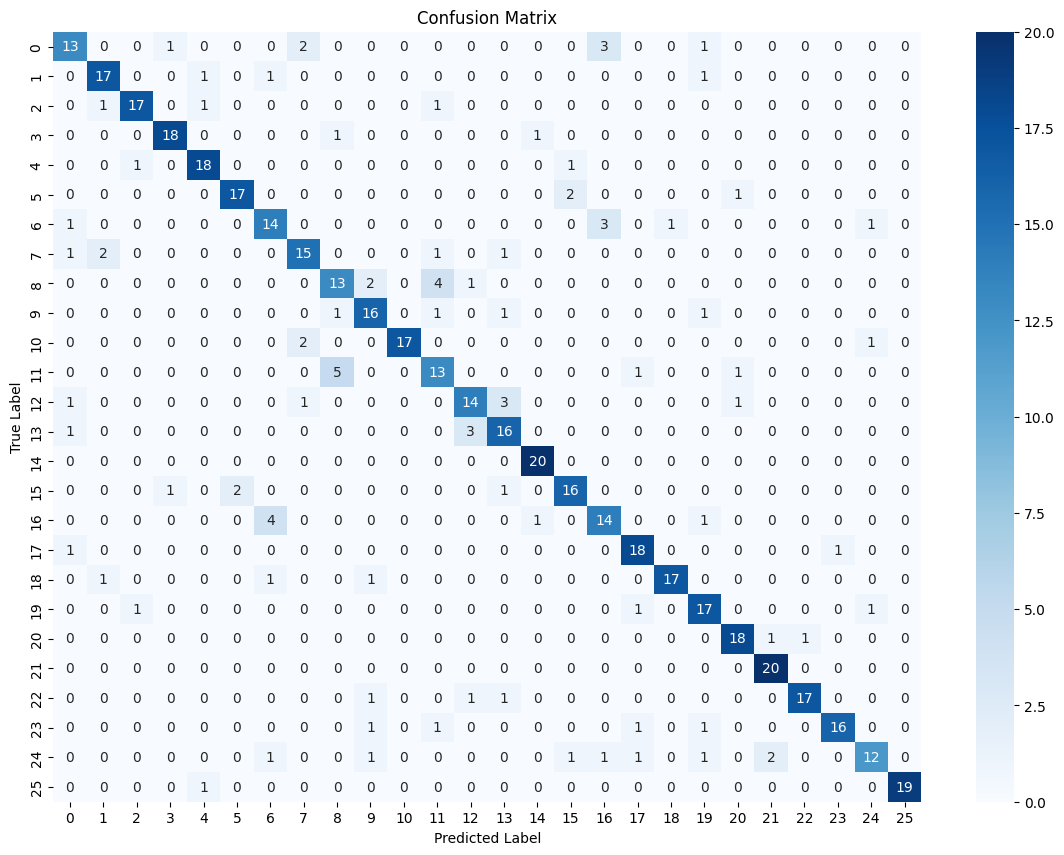


Confusion matrix saved
Classification report saved
Done.


In [21]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.savefig("results/confusion_matrix.png")
plt.show()

print("\nConfusion matrix saved")
print("Classification report saved")
print("Done.")